In [1]:
# 1️⃣ Basic libraries for data handling
import numpy as np               # For numerical operations
import pandas as pd              # For data manipulation and loading CSVs

# 2️⃣ Libraries for data visualization
import matplotlib.pyplot as plt  # For plotting graphs
import seaborn as sns            # For more advanced visualization

# 3️⃣ Libraries for preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# 4️⃣ Machine learning models (for stacking hybrid model)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# 5️⃣ For ignoring warnings (optional but clean)
import warnings
warnings.filterwarnings('ignore')

# 6️⃣ Set plot style (optional)
sns.set_style('whitegrid')

In [4]:
# 1️⃣ Load the dataset
data = pd.read_csv('heart.csv')  # Adjust path if your CSV is elsewhere

# 2️⃣ View the first few rows
data.head()

# 3️⃣ Get a summary of the dataset
data.info()

# 4️⃣ Check for missing values
data.isnull().sum()

# 5️⃣ Quick statistical overview
data.describe()

# 6️⃣ Check class distribution (target variable)
data['target'].value_counts()  # replace 'target' with your label column name

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   float64
 1   sex                  1190 non-null   float64
 2   chest_pain_type      1190 non-null   float64
 3   resting_bp_s         1190 non-null   float64
 4   cholesterol          1190 non-null   float64
 5   fasting_blood_sugar  1190 non-null   float64
 6   resting_ecg          1190 non-null   float64
 7   max_heart_rate       1190 non-null   float64
 8   exercise_angina      1190 non-null   float64
 9   oldpeak              1190 non-null   float64
 10  st_slope             1190 non-null   float64
 11  target               1190 non-null   float64
dtypes: float64(12)
memory usage: 111.7 KB


target
1.0    629
0.0    561
Name: count, dtype: int64

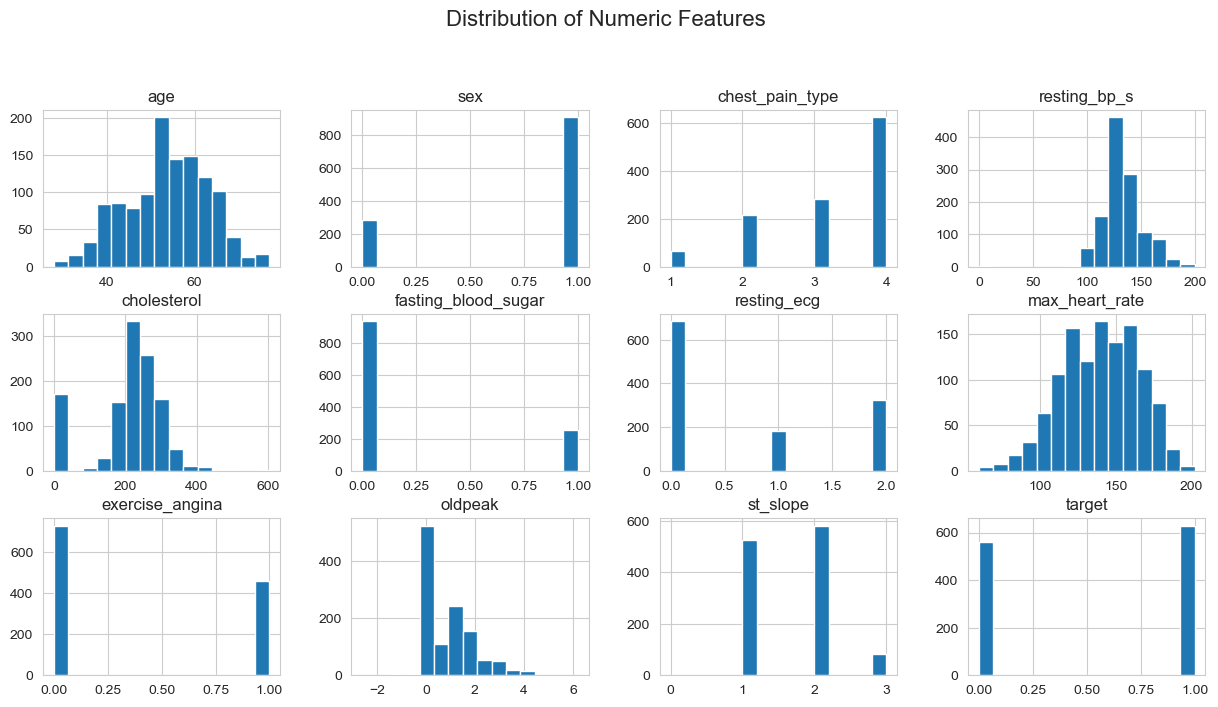

In [5]:
# 1️⃣ Distribution of numeric features
numeric_cols = data.select_dtypes(include=['int64','float64']).columns
data[numeric_cols].hist(bins=15, figsize=(15,10), layout=(4,4))
plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.show()

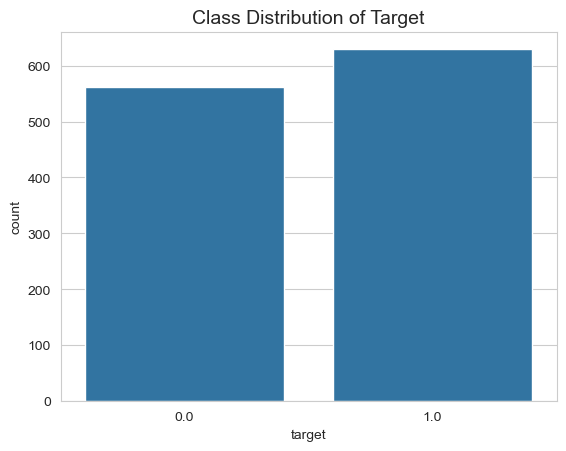

In [6]:
# 2️⃣ Count plot for target variable
sns.countplot(x='target', data=data)
plt.title('Class Distribution of Target', fontsize=14)
plt.show()

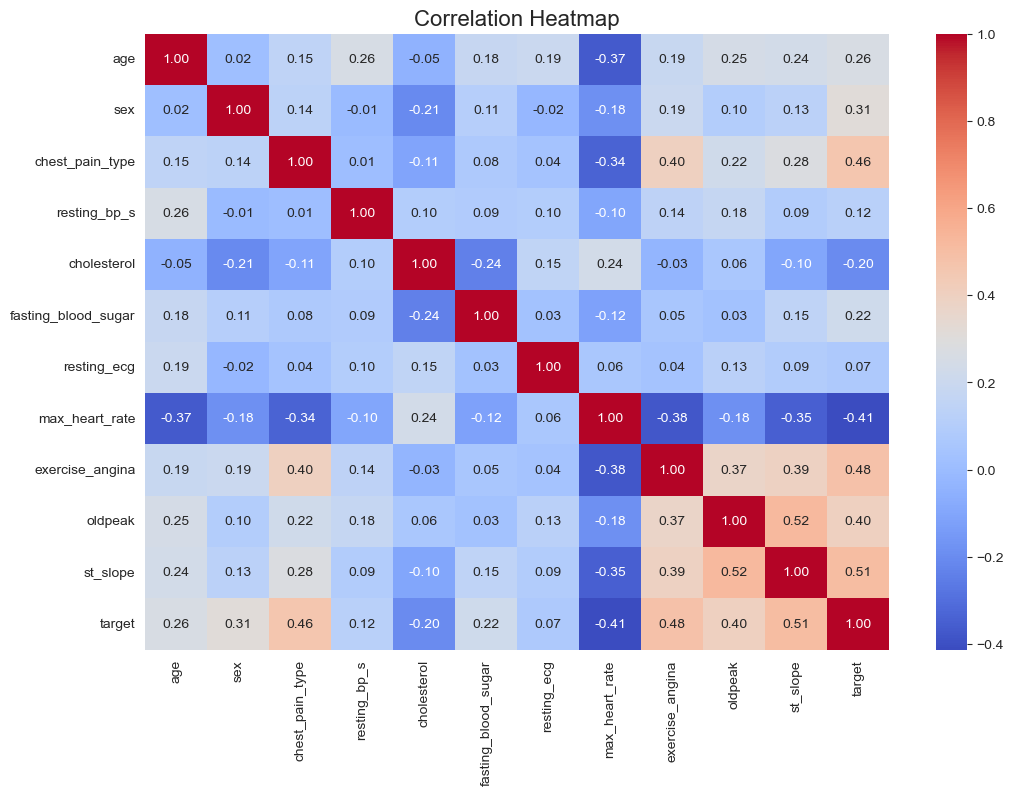

In [7]:
# 3️⃣ Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

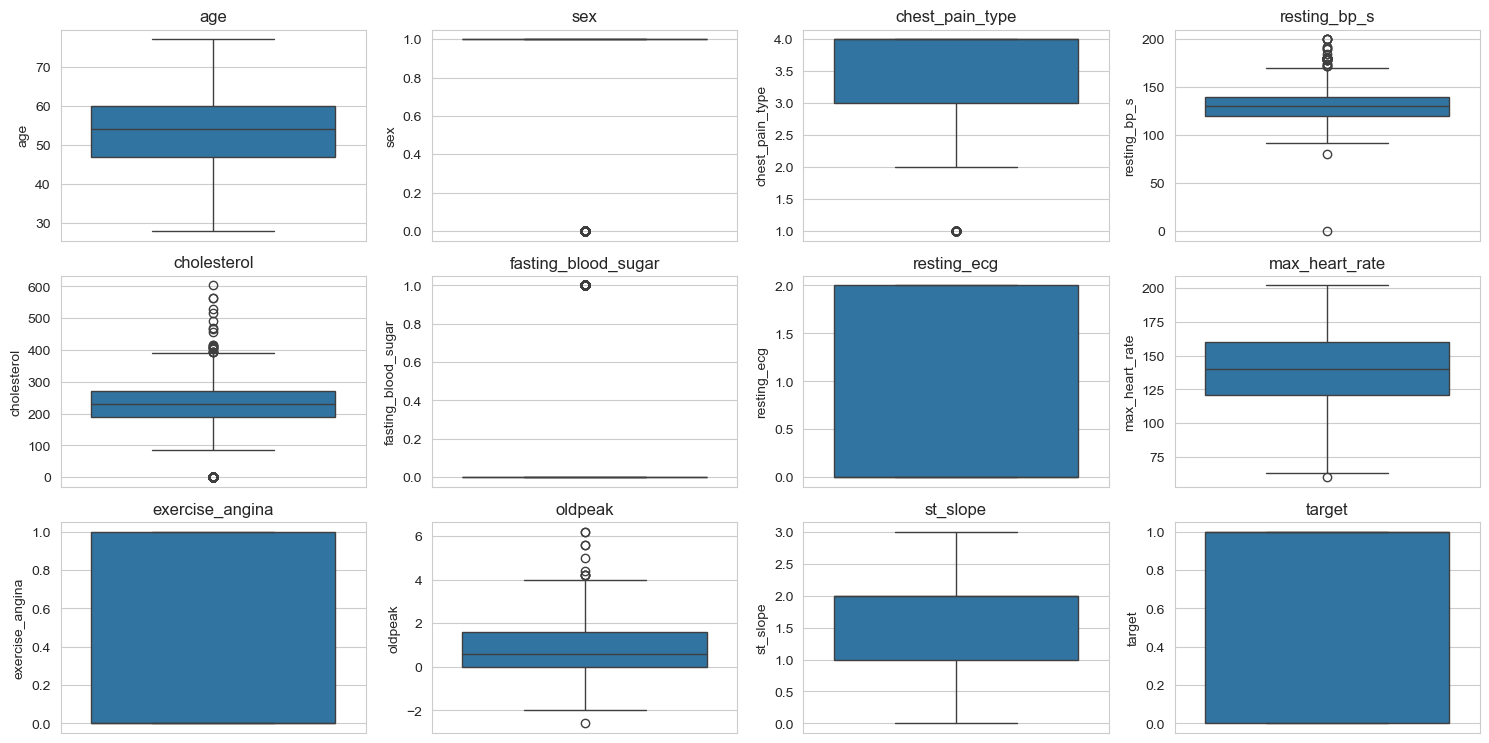

In [8]:
# 4️⃣ Boxplots to check outliers
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

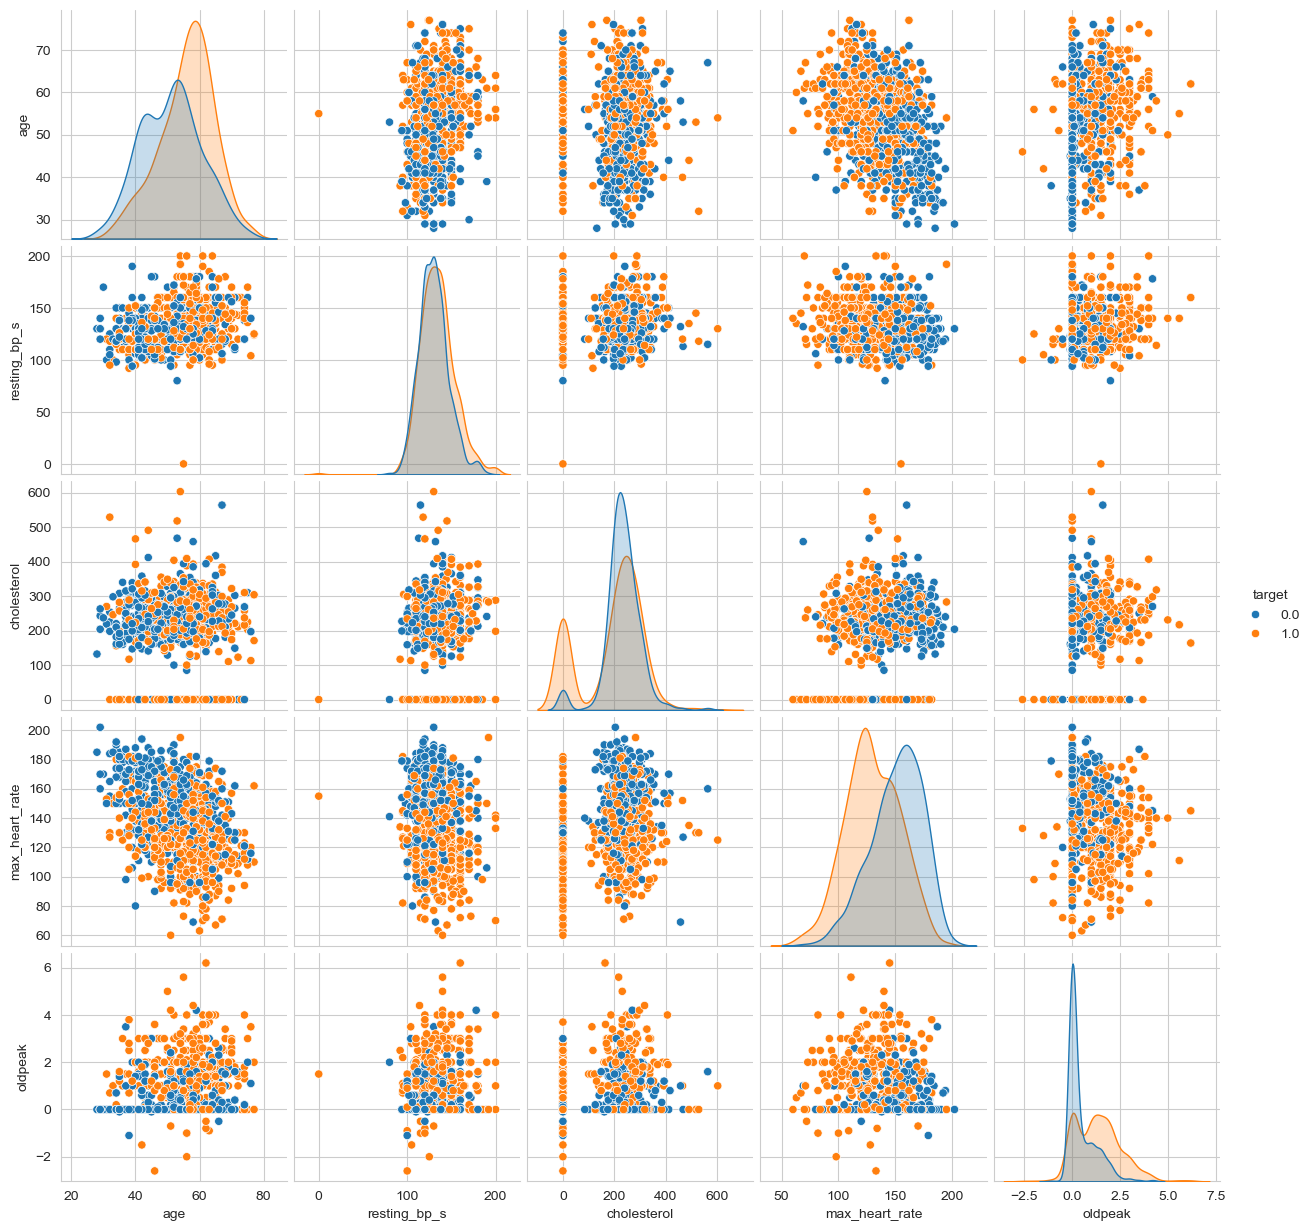

In [9]:
# 5️⃣ Pairplot (optional, for smaller datasets)
eda_features = [
    'age',
    'resting_bp_s',
    'cholesterol',
    'max_heart_rate',
    'oldpeak',
    'target'
]

sns.pairplot(data[eda_features], hue='target', diag_kind='kde')
plt.show()

In [10]:
data.isnull().sum()

age                    0
sex                    0
chest_pain_type        0
resting_bp_s           0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
oldpeak                0
st_slope               0
target                 0
dtype: int64

In [11]:
data.duplicated().sum()

272

In [12]:
data=data.drop_duplicates()

In [13]:
data.shape

(918, 12)

In [14]:
data["target"].value_counts()

target
1.0    508
0.0    410
Name: count, dtype: int64

In [15]:
# List all column names
print(data.columns)

Index(['age', 'sex', 'chest_pain_type', 'resting_bp_s', 'cholesterol',
       'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate',
       'exercise_angina', 'oldpeak', 'st_slope', 'target'],
      dtype='object')


In [16]:
# Check min and max for numeric features
for col in ['age', 'resting_bp_s', 'cholesterol', 'max_heart_rate']:
    print(f"{col} min: {data[col].min()}, max: {data[col].max()}")

age min: 28.0, max: 77.0
resting_bp_s min: 0.0, max: 200.0
cholesterol min: 0.0, max: 603.0
max_heart_rate min: 60.0, max: 202.0


In [17]:
# 1️⃣ Check the shape of the dataset
print("Dataset Shape:", data.shape)

# 2️⃣ Check for missing values
missing_values = data.isnull().sum()
print("\nMissing Values:\n", missing_values)

# 3️⃣ Check for duplicates
duplicates = data.duplicated().sum()
print("\nNumber of Duplicate Rows:", duplicates)

# 4️⃣ Check data types
print("\nData Types:\n", data.dtypes)

# 5️⃣ Summary statistics for numeric features
print("\nSummary Statistics:\n", data.describe())

# 6️⃣ Check for unique values in categorical features
categorical_cols = data.select_dtypes(include=['object','category']).columns
for col in categorical_cols:
    print(f"\nUnique values in {col}: {data[col].unique()}")

# 7️⃣ Check target balance (important for classification)
print("\nTarget Distribution:\n", data['target'].value_counts())


Dataset Shape: (918, 12)

Missing Values:
 age                    0
sex                    0
chest_pain_type        0
resting_bp_s           0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
oldpeak                0
st_slope               0
target                 0
dtype: int64

Number of Duplicate Rows: 0

Data Types:
 age                    float64
sex                    float64
chest_pain_type        float64
resting_bp_s           float64
cholesterol            float64
fasting_blood_sugar    float64
resting_ecg            float64
max_heart_rate         float64
exercise_angina        float64
oldpeak                float64
st_slope               float64
target                 float64
dtype: object

Summary Statistics:
               age         sex  chest_pain_type  resting_bp_s  cholesterol  \
count  918.000000  918.000000       918.000000    918.000000   918.000000   
mean    53.510893    0.789760         3

Data Quality Check Observations:

Dataset size: The dataset contains 918 samples after cleaning (previously 1,190 samples).

Target distribution: After cleaning, the target variable has 508 samples with heart disease (1) and 410 samples without (0), showing a slight class imbalance.

Missing values: No missing values were found across any features.

Duplicates: All duplicate rows were removed.

Numeric features: All numeric columns (age, resting_bp_s, cholesterol, max_heart_rate, etc.) are within reasonable ranges for clinical data.

Categorical features: Categorical variables (sex, chest_pain_type, exercise_angina, st_slope, etc.) have valid and consistent entries.

✅ Conclusion: The dataset is clean, consistent, and ready for preprocessing and modeling.

In [18]:
# Separate features (X) and target (y)
X = data.drop('target', axis=1)
y = data['target']

# Encode categorical features if needed
# List of categorical columns
categorical_cols = ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'resting_ecg',
                    'exercise_angina', 'st_slope']

# Use one-hot encoding for categorical variables
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Check final feature set
X.head()

,age,resting_bp_s,cholesterol,max_heart_rate,oldpeak,sex_1.0,chest_pain_type_2.0,chest_pain_type_3.0,chest_pain_type_4.0,fasting_blood_sugar_1.0,resting_ecg_1.0,resting_ecg_2.0,exercise_angina_1.0,st_slope_1.0,st_slope_2.0,st_slope_3.0
0,40.0,140.0,289.0,172.0,0.0,True,True,False,False,False,False,False,False,True,False,False
1,49.0,160.0,180.0,156.0,1.0,False,False,True,False,False,False,False,False,False,True,False
2,37.0,130.0,283.0,98.0,0.0,True,True,False,False,False,True,False,False,True,False,False
3,48.0,138.0,214.0,108.0,1.5,False,False,False,True,False,False,False,True,False,True,False
4,54.0,150.0,195.0,122.0,0.0,True,False,True,False,False,False,False,False,True,False,False


In [19]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model
rf_model.fit(X, y)

# Get feature importances
importances = rf_model.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
feature_importance_df

,Feature,Importance
13,st_slope_1.0,0.162112
3,max_heart_rate,0.102398
2,cholesterol,0.101058
14,st_slope_2.0,0.100520
4,oldpeak,0.095196
8,chest_pain_type_4.0,0.093446
0,age,0.075394
1,resting_bp_s,0.070477
12,exercise_angina_1.0,0.070458
5,sex_1.0,0.036765


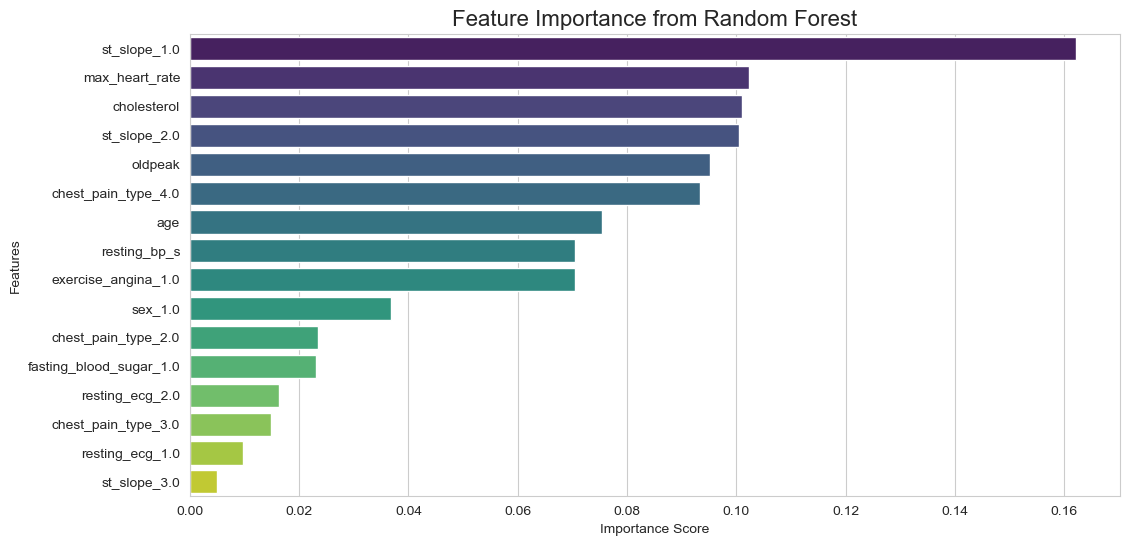

In [20]:
# Plot feature importance
plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance from Random Forest', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [21]:
# Features and target
X = data.drop('target', axis=1)
y = data['target']

In [22]:
# Check for missing values
print(X.isnull().sum())

# If missing values exist, you can fill them
# For numeric columns, use mean/median
numeric_cols = X.select_dtypes(include=['int64','float64']).columns
for col in numeric_cols:
    X[col].fillna(X[col].median(), inplace=True)

# For categorical columns, use mode
categorical_cols = X.select_dtypes(include=['object','category']).columns
for col in categorical_cols:
    X[col].fillna(X[col].mode()[0], inplace=True)

age                    0
sex                    0
chest_pain_type        0
resting_bp_s           0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
oldpeak                0
st_slope               0
dtype: int64


In [23]:
# Identify categorical columns
categorical_cols = ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'resting_ecg',
                    'exercise_angina', 'st_slope']

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [24]:
from sklearn.model_selection import train_test_split

# Stratify ensures class balance in train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (734, 16)
Test set size: (184, 16)


In [25]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit only on training data, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
# Save preprocessed arrays for reuse
import joblib

joblib.dump(X_train_scaled, 'X_train_scaled.pkl')
joblib.dump(X_test_scaled, 'X_test_scaled.pkl')
joblib.dump(y_train, 'y_train.pkl')
joblib.dump(y_test, 'y_test.pkl')

['y_test.pkl']

Data Preprocessing

Before training machine learning models, the dataset was preprocessed to ensure data quality and compatibility with algorithms.

Missing values were handled using median imputation. The dataset was then separated into feature variables (X) and the target variable (y).

To ensure consistent feature scales, StandardScaler was applied to normalize the numerical attributes. Finally, the dataset was divided into training and testing subsets using an 80–20 split to allow reliable evaluation of model performance.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Define models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

# Train and store results
baseline_results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    baseline_results[name] = accuracy_score(y_test, y_pred)

# Show baseline accuracy
baseline_results

{'Logistic Regression': 0.8858695652173914,
 'Decision Tree': 0.7771739130434783,
 'Random Forest': 0.8695652173913043,
 'Gradient Boosting': 0.8858695652173914,
 'XGBoost': 0.8641304347826086,
 'SVM': 0.8913043478260869}

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1] if hasattr(model, "predict_proba") else None
    print(f"--- {name} ---")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    if y_prob is not None:
        print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))
    print("\n")

--- Logistic Regression ---
Confusion Matrix:
 [[68 14]
 [ 7 95]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.83      0.87        82
         1.0       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184

ROC-AUC Score: 0.9295791487326638


--- Decision Tree ---
Confusion Matrix:
 [[61 21]
 [20 82]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.75      0.74      0.75        82
         1.0       0.80      0.80      0.80       102

    accuracy                           0.78       184
   macro avg       0.77      0.77      0.77       184
weighted avg       0.78      0.78      0.78       184

ROC-AUC Score: 0.7739120038259206


--- Random Forest ---
Confusion Matrix:
 [[68 14]
 [10 92]]
Classification Report:
               pr

In [29]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv_results = {}
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='accuracy')
    cv_results[name] = scores.mean()

cv_results

{'Logistic Regression': 0.848802534712515,
 'Decision Tree': 0.7915292144254963,
 'Random Forest': 0.8515236231478893,
 'Gradient Boosting': 0.8542819867673096,
 'XGBoost': 0.847423352902805,
 'SVM': 0.8447115832634424}

In [30]:
from sklearn.model_selection import GridSearchCV

# Example: Random Forest tuning
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5, scoring='accuracy')
rf_grid.fit(X_train_scaled, y_train)

print("Best RF Params:", rf_grid.best_params_)
print("Best RF CV Accuracy:", rf_grid.best_score_)

Best RF Params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV Accuracy: 0.8650638337526791


In [31]:
# Re-train best RF
best_rf = rf_grid.best_estimator_
best_rf.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_best_rf = best_rf.predict(X_test_scaled)
accuracy_score(y_test, y_pred_best_rf)

0.875

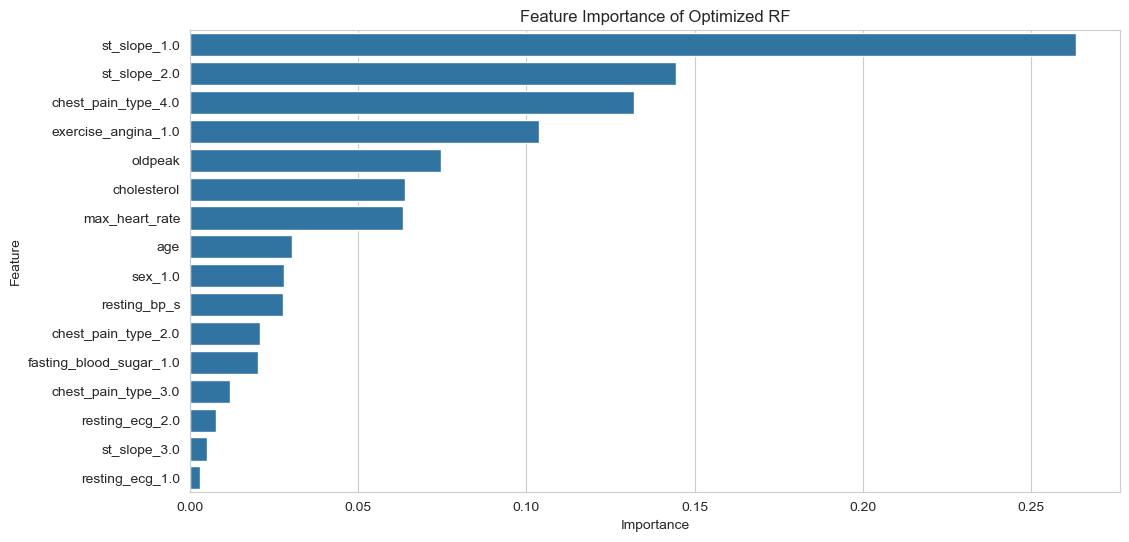

In [32]:
importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_train_scaled.shape[1]*[None], 'Importance': importances})
feature_importance_df['Feature'] = X.columns
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance of Optimized RF')
plt.show()

In [33]:
from sklearn.ensemble import StackingClassifier

# Base learners
base_learners = [
    ('lr', LogisticRegression(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
]

# Meta learner
meta_learner = GradientBoostingClassifier(n_estimators=100, random_state=42)

stack_model = StackingClassifier(estimators=base_learners, final_estimator=meta_learner, cv=5)
stack_model.fit(X_train_scaled, y_train)

# Test performance
y_pred_stack = stack_model.predict(X_test_scaled)
print("Stacking Model Accuracy:", accuracy_score(y_test, y_pred_stack))
print(classification_report(y_test, y_pred_stack))

Stacking Model Accuracy: 0.8804347826086957
              precision    recall  f1-score   support

         0.0       0.92      0.80      0.86        82
         1.0       0.86      0.94      0.90       102

    accuracy                           0.88       184
   macro avg       0.89      0.87      0.88       184
weighted avg       0.88      0.88      0.88       184



In [34]:
# Combine all results
final_results = {
    "Baseline Accuracy": baseline_results,
    "Cross-Validated Accuracy": cv_results,
    "Stacking Model Accuracy": accuracy_score(y_test, y_pred_stack)
}

final_results

{'Baseline Accuracy': {'Logistic Regression': 0.8858695652173914,
  'Decision Tree': 0.7771739130434783,
  'Random Forest': 0.8695652173913043,
  'Gradient Boosting': 0.8858695652173914,
  'XGBoost': 0.8641304347826086,
  'SVM': 0.8913043478260869},
 'Cross-Validated Accuracy': {'Logistic Regression': 0.848802534712515,
  'Decision Tree': 0.7915292144254963,
  'Random Forest': 0.8515236231478893,
  'Gradient Boosting': 0.8542819867673096,
  'XGBoost': 0.847423352902805,
  'SVM': 0.8447115832634424},
 'Stacking Model Accuracy': 0.8804347826086957}

In [35]:
import joblib

# Save stacking model and scaler
joblib.dump(stack_model, 'heart_disease_stack_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Later, you can load them:
# stack_model = joblib.load('heart_disease_stack_model.pkl')
# scaler = joblib.load('scaler.pkl')

['scaler.pkl']